In [1]:

import math
import re
import pandas as pd

df = pd.read_csv('data_bds.csv')

def parse_price(value):
    if pd.isna(value):
        return math.nan, None

    text = str(value).strip().lower()
    if not text or text in {'thoả thuận', 'thỏa thuận'}:
        return math.nan, None

    text = text.replace('~', '').replace(' ', '')
    text = text.replace('triệu/m²', 'trieu/m2')
    text = text.replace('nghìn/m²', 'nghin/m2')
    text = text.replace('tỷ/m²', 'ty/m2')
    text = text.replace('tỷđồng', 'ty')
    text = text.replace('triệu', 'trieu')
    text = text.replace('nghìn', 'nghin')
    text = text.replace('tỷ', 'ty')

    match = re.search(r'([\d.,]+)(?=ty/m2)', text)
    if match:
        return float(match.group(1).replace('.', '').replace(',', '.')), 'ty_m2'

    match = re.search(r'([\d.,]+)(?=trieu/m2)', text)
    if match:
        return float(match.group(1).replace('.', '').replace(',', '.')), 'trieu_m2'

    match = re.search(r'([\d.,]+)(?=nghin/m2)', text)
    if match:
        return float(match.group(1).replace('.', '').replace(',', '.')), 'nghin_m2'

    match = re.search(r'([\d.,]+)(?=ty)', text)
    if match:
        return float(match.group(1).replace('.', '').replace(',', '.')), 'ty'

    match = re.search(r'([\d.,]+)(?=trieu)', text)
    if match:
        return float(match.group(1).replace('.', '').replace(',', '.')), 'trieu'

    match = re.search(r'([\d.,]+)(?=nghin)', text)
    if match:
        return float(match.group(1).replace('.', '').replace(',', '.')), 'nghin'

    match = re.search(r'[\d.,]+', text)
    if match:
        return float(match.group(0).replace('.', '').replace(',', '.')), None

    return math.nan, None

def normalize_price(value, unit, target):
    if pd.isna(value):
        return math.nan

    if target == 'ty':
        if unit == 'ty':
            return value
        if unit == 'trieu':
            return value / 1000.0
        if unit == 'nghin':
            return value / 1_000_000.0
        return value

    if target == 'trieu_m2':
        if unit == 'ty_m2':
            return value * 1000.0
        if unit == 'trieu_m2':
            return value
        if unit == 'nghin_m2':
            return value / 1000.0
        return value

    return value

def normalize_row(row):
    price_val, price_unit = parse_price(row['Mức giá'])
    unit_val, unit_unit = parse_price(row['Giá/m²'])

    full_units = {'ty', 'trieu', 'nghin'}
    sqm_units = {'ty_m2', 'trieu_m2', 'nghin_m2'}

    # Swap if the columns are clearly flipped.
    if price_unit in sqm_units and unit_unit in full_units:
        price_val, unit_val = unit_val, price_val
        price_unit, unit_unit = unit_unit, price_unit

    row['Mức giá'] = normalize_price(price_val, price_unit, 'ty')
    row['Giá/m²'] = normalize_price(unit_val, unit_unit, 'trieu_m2')
    return row

df = df.apply(normalize_row, axis=1)
df


,Link,Tiêu đề,Địa chỉ,Địa chỉ 1,Địa chỉ 2,Mức giá,Giá/m²,Số phòng ngủ,Huyện,Diện tích,...,Hướng ban công,Số tầng,Số toilet,Pháp lý,Ngày đăng,Ngày hết hạn,Loại tin,Mã tin,Latitude,Longitude
0,https://batdongsan.com.vn/ban-dat-duong-tinh-l...,Đất nền đô thị khu Hòa Lạc vị trí vàng đón són...,"Đường Tỉnh Lộ 446, Xã Phú Cát, Huyện Quốc Oai,...","Đường Tỉnh Lộ 446, Xã Phú Cát, Huyện Quốc Oai,...","(Xã Phú Cát, Hà Nội mới)",3.80,38.00,NaN,Quốc Oai,100 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,31/05/2026,15/06/2026,Tin VIP Kim Cương,45777009,20.971660,105.553368
1,https://batdongsan.com.vn/ban-dat-xa-phuong-so...,Tôi bán gấp ô đất vuông như phân lô tại Thôn B...,"Thôn Ba Nhà, Xã Phượng Sơn, Huyện Quốc Oai, Hà...","Thôn Ba Nhà, Xã Phượng Sơn, Huyện Quốc Oai, Hà...","(Xã Quốc Oai, Hà Nội mới)",4.74,39.50,NaN,Quốc Oai,120 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,03/06/2026,18/06/2026,Tin VIP Vàng,45367770,20.989828,105.665662
2,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Bán gấp nhà ngõ 301 Trường Chinh 55m2 x 5tầng,...","Đường Trường Chinh, Phường Phương Liệt, Quận T...","Đường Trường Chinh, Phường Phương Liệt, Quận T...","(Phường Phương Liệt, Hà Nội mới)",13.80,250.91,6 phòng,Thanh Xuân,55 m²,...,NaN,5 tầng,NaN,Sổ đỏ/ Sổ hồng,14/06/2026,21/06/2026,Tin VIP Vàng,45907823,20.998569,105.837763
3,https://batdongsan.com.vn/ban-dat-xa-tan-xa/ba...,Bán gấp 151m2 mảnh đất vàng mặt hồ Tân Xã nơi ...,"Xã Tân Xã, Huyện Thạch Thất, Hà Nội | (Xã Hòa ...","Xã Tân Xã, Huyện Thạch Thất, Hà Nội","(Xã Hòa Lạc, Hà Nội mới)",25.00,165.56,NaN,Thạch Thất,151 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,11/06/2026,18/06/2026,Tin VIP Kim Cương,45895853,21.019479,105.545057
4,https://batdongsan.com.vn/ban-dat-duong-quoc-l...,"Hiếm! Lô đất lõi khu CNC Hòa Lạc, sát QL21A, c...","Đường Quốc lộ 21A(Quốc lộ 21), Xã Phú Cát, Huy...","Đường Quốc lộ 21A(Quốc lộ 21), Xã Phú Cát, Huy...","(Xã Phú Cát, Hà Nội mới)",2.30,20.00,NaN,Quốc Oai,115 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,07/06/2026,14/06/2026,Tin thường,45870806,20.967998,105.535693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,https://batdongsan.com.vn/ban-dat-phuong-kim-s...,Em cần bán gấp - giá bán cắt lỗ - lô đất giãn ...,"Phường Kim Sơn, Thị xã Sơn Tây, Hà Nội | (Xã Đ...","Phường Kim Sơn, Thị xã Sơn Tây, Hà Nội","(Xã Đoài Phương, Hà Nội mới)",1.80,22.50,NaN,Sơn Tây,80 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,31/05/2026,15/06/2026,Tin thường,44987006,21.078375,105.462794
1413,https://batdongsan.com.vn/ban-dat-xa-phu-cat-1...,"Bán đất tại Thôn 4, Xã Phú Cát, Huyện Quốc Oai...","Thôn 4, Xã Phú Cát, Huyện Quốc Oai, Hà Nội | (...","Thôn 4, Xã Phú Cát, Huyện Quốc Oai, Hà Nội","(Xã Phú Cát, Hà Nội mới)",2.70,27.00,NaN,Quốc Oai,100 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,31/05/2026,15/06/2026,Tin thường,45573474,20.974650,105.552859
1414,https://batdongsan.com.vn/ban-dat-xa-co-dong/h...,"HC13. Chỉ 2,8 tỷ sở hữu đất trung tâm đại học ...","Xã Cổ Đông, Thị xã Sơn Tây, Hà Nội | (Xã Đoài ...","Xã Cổ Đông, Thị xã Sơn Tây, Hà Nội","(Xã Đoài Phương, Hà Nội mới)",2.80,26.77,NaN,Sơn Tây,"104,6 m²",...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,31/05/2026,15/06/2026,Tin thường,45656189,21.059562,105.515578
1415,https://batdongsan.com.vn/ban-dat-xa-co-dong/a...,"Đất Cổ Đông 103m² gần ĐHQG Hòa Lạc MT 5m, đườn...","Xã Cổ Đông, Thị xã Sơn Tây, Hà Nội | (Xã Đoài ...","Xã Cổ Đông, Thị xã Sơn Tây, Hà Nội","(Xã Đoài Phương, Hà Nội mới)",3.07,29.80,NaN,Sơn Tây,103 m²,...,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,31/05/2026,15/06/2026,Tin thường,45716731,21.059497,105.515478


In [2]:
df['Pháp lý'].unique()

array(['Sổ đỏ/ Sổ hồng', 'Sổ đỏ.', nan, 'Sổ đỏ', 'Sổ đỏ/ Sổ hồng.',
       'Sổ đỏ pháp lý rõ ràng', 'Sổ hồng riêng', 'Sổ đỏ chính chủ',
       'Sổ đỏ/ Sổ hồng', 'Sổ đỏ đầy đủ.', 'Chưa sổ',
       'Hợp đồng mua bán', 'Sổ đỏ/sổ Hồng', 'Sổ đỏ chính chủ.',
       'Sổ vuông vắn.', 'ĐÃ CÓ SỔ', 'Sổ đỏ chính chủ pháp lý rõ ràng.',
       'Sổ đỏ riêng biệt.', 'Sổ hồng', 'Có sổ.', 'Có sổ',
       'Sổ đỏ, sổ hồng', 'Sổ đỏ riêng, sẵn sàng giao dịch.', 'Sổ đỏ sdc',
       'Sổ hồng.', 'Sổ chính chủ', 'Sổ đỏ/sổ hồng', 'Sđcc',
       'Sổ đỏ/ Sổ hồng sdc', 'Sổ đỏ sẵn giao dịch ngay.', 'SĐCC',
       'Sổ đỏ sẵn.', 'Sổ đỏ riêng biệt, pháp lý rõ ràng',
       'Sổ đỏ/sổ hồng chung', 'Sổ đỏ/ Sổ hồng chung'], dtype=object)

In [3]:
df['Giá/m²'] = pd.to_numeric(df['Giá/m²'], errors='coerce')

In [4]:
df.groupby("Huyện")["Giá/m²"].agg(['mean', 'count']).sort_values(by='mean', ascending=False).reset_index()

,Huyện,mean,count
0,Hoàn Kiếm,581.250000,2
1,Tây Hồ,354.664583,24
2,Cầu Giấy,350.229444,72
3,Đống Đa,342.007467,75
4,Thanh Xuân,328.420435,23
5,Ba Đình,319.227692,52
6,Hai Bà Trưng,264.610000,32
7,Nam Từ Liêm,263.356444,45
8,Hoàng Mai,248.413333,42
9,Bắc Từ Liêm,243.482174,23


In [5]:

import math
import pandas as pd

THAP_RUA_LAT = 21.0255923
THAP_RUA_LON = 105.8464321

def haversine_km(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return math.nan

    r = 6371.0
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = (
        math.sin(dphi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * r * math.asin(math.sqrt(a))

def bearing_degrees(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return math.nan

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dlambda = math.radians(lon2 - lon1)

    x = math.sin(dlambda) * math.cos(phi2)
    y = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dlambda)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def bearing_to_direction(bearing):
    if pd.isna(bearing):
        return pd.NA

    directions = [
        'North', 'Northeast', 'East', 'Southeast',
        'South', 'Southwest', 'West', 'Northwest'
    ]
    index = int((bearing + 22.5) // 45) % 8
    return directions[index]

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

df['dist_to_HN_center'] = df.apply(
    lambda row: haversine_km(
        row['Latitude'],
        row['Longitude'],
        THAP_RUA_LAT,
        THAP_RUA_LON,
    ),
    axis=1,
)

df['direction_to_HN_center'] = df.apply(
    lambda row: bearing_to_direction(
        bearing_degrees(
            THAP_RUA_LAT,
            THAP_RUA_LON,
            row['Latitude'],
            row['Longitude'],
        )
    ),
    axis=1,
)

df[['Latitude', 'Longitude', 'dist_to_HN_center', 'direction_to_HN_center']]


,Latitude,Longitude,dist_to_HN_center,direction_to_HN_center
0,20.971660,105.553368,31.008548,West
1,20.989828,105.665662,19.181469,West
2,20.998569,105.837763,3.136704,South
3,21.019479,105.545057,31.288245,West
4,20.967998,105.535693,32.887874,West
...,...,...,...,...
1412,21.078375,105.462794,40.241671,West
1413,20.974650,105.552859,30.997584,West
1414,21.059562,105.515578,34.543135,West
1415,21.059497,105.515478,34.552578,West


Rows after cleaning: 1162


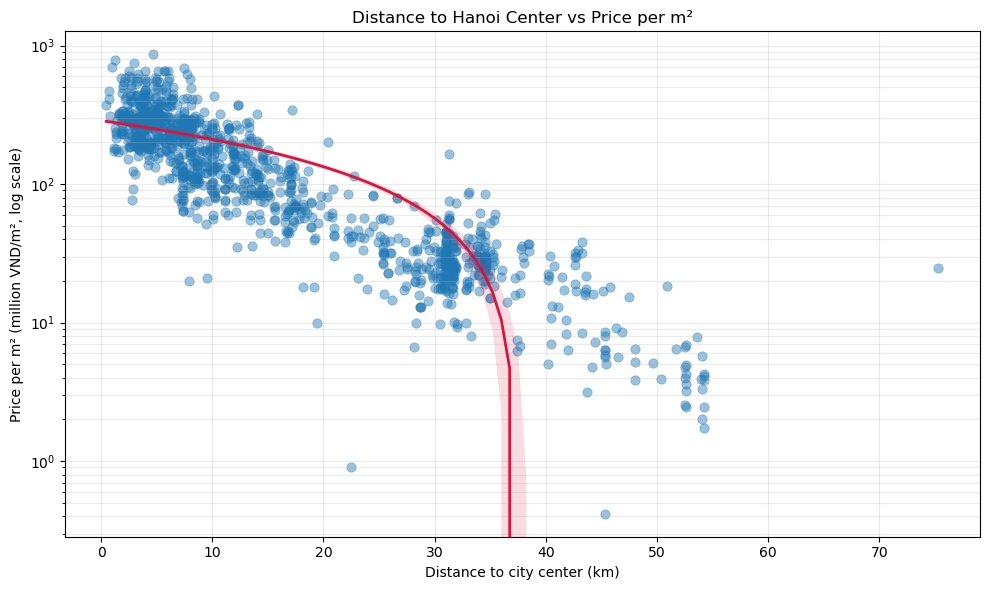

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_df = df[['dist_to_HN_center', 'Giá/m²', 'Latitude', 'Longitude', 'Địa chỉ']].copy()
plot_df['dist_to_HN_center'] = pd.to_numeric(plot_df['dist_to_HN_center'], errors='coerce')
plot_df['Giá/m²'] = pd.to_numeric(plot_df['Giá/m²'], errors='coerce')
plot_df['Latitude'] = pd.to_numeric(plot_df['Latitude'], errors='coerce')
plot_df['Longitude'] = pd.to_numeric(plot_df['Longitude'], errors='coerce')

plot_df = plot_df.dropna(subset=['dist_to_HN_center', 'Giá/m²', 'Latitude', 'Longitude', 'Địa chỉ'])
plot_df = plot_df[plot_df['dist_to_HN_center'] < 80]
plot_df = plot_df.drop_duplicates(subset=['Latitude', 'Longitude', 'Địa chỉ'])
plot_df = plot_df[plot_df['Giá/m²'] > 0]

print(f'Rows after cleaning: {len(plot_df)}')

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=plot_df,
    x='dist_to_HN_center',
    y='Giá/m²',
    alpha=0.45,
    s=45,
    edgecolor=None,
)

sns.regplot(
    data=plot_df,
    x='dist_to_HN_center',
    y='Giá/m²',
    scatter=False,
    color='crimson',
    line_kws={'linewidth': 2},
    ax=ax,
)

ax.set_yscale('log')
ax.set_title('Distance to Hanoi Center vs Price per m²')
ax.set_xlabel('Distance to city center (km)')
ax.set_ylabel('Price per m² (million VND/m², log scale)')
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()
